In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore') # Hides unnecessary seaborn warnings

# 1. Base Countries Dictionary (Full Complete List)
countries = [
    {"country": "United States", "iso_code": "USA", "latitude": 37.1, "longitude": -95.7, "region": "North America"},
    {"country": "Canada", "iso_code": "CAN", "latitude": 56.1, "longitude": -106.3, "region": "North America"},
    {"country": "Mexico", "iso_code": "MEX", "latitude": 23.6, "longitude": -102.5, "region": "Latin America"},
    {"country": "Brazil", "iso_code": "BRA", "latitude": -14.2, "longitude": -51.9, "region": "Latin America"},
    {"country": "Argentina", "iso_code": "ARG", "latitude": -38.4, "longitude": -63.6, "region": "Latin America"},
    {"country": "Colombia", "iso_code": "COL", "latitude": 4.6, "longitude": -74.1, "region": "Latin America"},
    {"country": "Chile", "iso_code": "CHL", "latitude": -35.7, "longitude": -71.5, "region": "Latin America"},
    {"country": "United Kingdom", "iso_code": "GBR", "latitude": 55.4, "longitude": -3.4, "region": "Europe"},
    {"country": "France", "iso_code": "FRA", "latitude": 46.2, "longitude": 2.2, "region": "Europe"},
    {"country": "Germany", "iso_code": "DEU", "latitude": 51.2, "longitude": 10.5, "region": "Europe"},
    {"country": "Italy", "iso_code": "ITA", "latitude": 41.9, "longitude": 12.6, "region": "Europe"},
    {"country": "Spain", "iso_code": "ESP", "latitude": 40.5, "longitude": -3.7, "region": "Europe"},
    {"country": "Norway", "iso_code": "NOR", "latitude": 60.5, "longitude": 8.5, "region": "Europe"},
    {"country": "Sweden", "iso_code": "SWE", "latitude": 60.1, "longitude": 18.6, "region": "Europe"},
    {"country": "Finland", "iso_code": "FIN", "latitude": 61.9, "longitude": 25.7, "region": "Europe"},
    {"country": "Russia", "iso_code": "RUS", "latitude": 61.5, "longitude": 105.3, "region": "Europe/Asia"},
    {"country": "China", "iso_code": "CHN", "latitude": 35.9, "longitude": 104.2, "region": "Asia"},
    {"country": "Japan", "iso_code": "JPN", "latitude": 36.2, "longitude": 138.3, "region": "Asia"},
    {"country": "India", "iso_code": "IND", "latitude": 20.6, "longitude": 78.9, "region": "Asia"},
    {"country": "Indonesia", "iso_code": "IDN", "latitude": -0.8, "longitude": 113.9, "region": "Asia"},
    {"country": "Singapore", "iso_code": "SGP", "latitude": 1.3, "longitude": 103.8, "region": "Asia"},
    {"country": "Thailand", "iso_code": "THA", "latitude": 15.9, "longitude": 101.0, "region": "Asia"},
    {"country": "Vietnam", "iso_code": "VNM", "latitude": 14.1, "longitude": 108.3, "region": "Asia"},
    {"country": "United Arab Emirates", "iso_code": "ARE", "latitude": 23.4, "longitude": 53.8, "region": "Middle East"},
    {"country": "Nigeria", "iso_code": "NGA", "latitude": 9.1, "longitude": 8.7, "region": "Africa"},
    {"country": "Kenya", "iso_code": "KEN", "latitude": -0.0, "longitude": 37.9, "region": "Africa"},
    {"country": "Egypt", "iso_code": "EGY", "latitude": 26.8, "longitude": 30.8, "region": "Africa"},
    {"country": "South Africa", "iso_code": "ZAF", "latitude": -30.6, "longitude": 22.9, "region": "Africa"},
    {"country": "Australia", "iso_code": "AUS", "latitude": -25.3, "longitude": 133.8, "region": "Oceania"},
    {"country": "New Zealand", "iso_code": "NZL", "latitude": -40.9, "longitude": 174.9, "region": "Oceania"},
    {"country": "Luxembourg", "iso_code": "LUX", "latitude": 49.8, "longitude": 6.1, "region": "Europe"},
    {"country": "Ireland", "iso_code": "IRL", "latitude": 53.4, "longitude": -8.2, "region": "Europe"},
    {"country": "Switzerland", "iso_code": "CHE", "latitude": 46.8, "longitude": 8.2, "region": "Europe"},
    {"country": "Denmark", "iso_code": "DNK", "latitude": 56.3, "longitude": 9.5, "region": "Europe"},
    {"country": "Netherlands", "iso_code": "NLD", "latitude": 52.1, "longitude": 5.3, "region": "Europe"},
    {"country": "Austria", "iso_code": "AUT", "latitude": 47.5, "longitude": 14.6, "region": "Europe"},
    {"country": "Belgium", "iso_code": "BEL", "latitude": 50.5, "longitude": 4.5, "region": "Europe"},
    {"country": "Iceland", "iso_code": "ISL", "latitude": 64.9, "longitude": -19.0, "region": "Europe"},
    {"country": "Qatar", "iso_code": "QAT", "latitude": 25.4, "longitude": 51.2, "region": "Middle East"},
    {"country": "Kuwait", "iso_code": "KWT", "latitude": 29.3, "longitude": 47.5, "region": "Middle East"},
    {"country": "Bahrain", "iso_code": "BHR", "latitude": 26.1, "longitude": 50.6, "region": "Middle East"},
    {"country": "Saudi Arabia", "iso_code": "SAU", "latitude": 23.9, "longitude": 45.1, "region": "Middle East"},
    {"country": "Israel", "iso_code": "ISR", "latitude": 31.0, "longitude": 35.0, "region": "Middle East"},
    {"country": "South Korea", "iso_code": "KOR", "latitude": 36.5, "longitude": 127.8, "region": "Asia"},
    {"country": "Hong Kong", "iso_code": "HKG", "latitude": 22.3, "longitude": 114.2, "region": "Asia"},
    {"country": "Taiwan", "iso_code": "TWN", "latitude": 23.7, "longitude": 121.0, "region": "Asia"},
    {"country": "Brunei", "iso_code": "BRN", "latitude": 4.5, "longitude": 114.7, "region": "Asia"},
    {"country": "Malta", "iso_code": "MLT", "latitude": 35.9, "longitude": 14.4, "region": "Europe"},
    {"country": "Cyprus", "iso_code": "CYP", "latitude": 35.1, "longitude": 33.4, "region": "Europe"},
    {"country": "Portugal", "iso_code": "PRT", "latitude": 39.4, "longitude": -8.2, "region": "Europe"},
    {"country": "Burundi", "iso_code": "BDI", "latitude": -3.4, "longitude": 29.9, "region": "Africa"},
    {"country": "Malawi", "iso_code": "MWI", "latitude": -13.3, "longitude": 34.3, "region": "Africa"},
    {"country": "Mozambique", "iso_code": "MOZ", "latitude": -18.7, "longitude": 35.5, "region": "Africa"},
    {"country": "Madagascar", "iso_code": "MDG", "latitude": -18.8, "longitude": 46.9, "region": "Africa"},
    {"country": "Central African Republic", "iso_code": "CAF", "latitude": 6.6, "longitude": 20.9, "region": "Africa"},
    {"country": "Niger", "iso_code": "NER", "latitude": 17.6, "longitude": 8.1, "region": "Africa"},
    {"country": "Mali", "iso_code": "MLI", "latitude": 17.6, "longitude": -3.9, "region": "Africa"},
    {"country": "Chad", "iso_code": "TCD", "latitude": 15.5, "longitude": 18.7, "region": "Africa"},
    {"country": "Liberia", "iso_code": "LBR", "latitude": 6.4, "longitude": -9.4, "region": "Africa"},
    {"country": "Sierra Leone", "iso_code": "SLE", "latitude": 8.5, "longitude": -11.8, "region": "Africa"},
    {"country": "Rwanda", "iso_code": "RWA", "latitude": -1.9, "longitude": 29.9, "region": "Africa"},
    {"country": "Uganda", "iso_code": "UGA", "latitude": 1.4, "longitude": 32.3, "region": "Africa"},
    {"country": "Ethiopia", "iso_code": "ETH", "latitude": 9.1, "longitude": 40.5, "region": "Africa"},
    {"country": "Tanzania", "iso_code": "TZA", "latitude": -6.4, "longitude": 34.9, "region": "Africa"},
    {"country": "Democratic Republic of Congo", "iso_code": "COD", "latitude": -4.0, "longitude": 21.8, "region": "Africa"},
    {"country": "Gambia", "iso_code": "GMB", "latitude": 13.4, "longitude": -15.3, "region": "Africa"},
    {"country": "Guinea-Bissau", "iso_code": "GNB", "latitude": 11.8, "longitude": -15.2, "region": "Africa"},
    {"country": "Togo", "iso_code": "TGO", "latitude": 8.6, "longitude": 0.8, "region": "Africa"},
    {"country": "Nepal", "iso_code": "NPL", "latitude": 28.4, "longitude": 84.1, "region": "Asia"},
    {"country": "Yemen", "iso_code": "YEM", "latitude": 15.6, "longitude": 48.5, "region": "Middle East"}
]
countries_df = pd.DataFrame(countries)

# 2. Fetch GDP via World Bank API
print("Fetching GDP Data from World Bank API...")
def fetch_gdp(iso_code):
    url = f"https://api.worldbank.org/v2/country/{iso_code}/indicator/NY.GDP.PCAP.CD?format=json&date=2022"
    
    try:
        response = requests.get(url, timeout=10)
        data = response.json()
        
        if len(data) > 1 and data[1] is not None and data[1][0]['value'] is not None:
            return {
                "iso_code": iso_code,
                "gdp_per_capita": data[1][0]['value']
            }
        
    except Exception as e:
        print(f"Could not fetch GDP for {iso_code}: {e}")
    
    return {
        "iso_code": iso_code,
        "gdp_per_capita": None
    }
    
# Build GDP dataframe by calling the World Bank API for each country
gdp_results = []

for iso_code in countries_df["iso_code"]:
    gdp_results.append(fetch_gdp(iso_code))

gdp_df = pd.DataFrame(gdp_results)

print("GDP dataframe created")
display(gdp_df.head())

# 3. Hardcoded HDI Values to bypass broken API
print("Loading HDI Data directly...")
hdi_mapping = {
    "USA": 0.921, "CAN": 0.936, "MEX": 0.758, "BRA": 0.754, "ARG": 0.842, "COL": 0.752, "CHL": 0.855,
    "GBR": 0.929, "FRA": 0.903, "DEU": 0.942, "ITA": 0.895, "ESP": 0.905, "NOR": 0.961, "SWE": 0.947, 
    "FIN": 0.940, "RUS": 0.822, "CHN": 0.768, "JPN": 0.925, "IND": 0.633, "IDN": 0.705, "SGP": 0.939, 
    "THA": 0.800, "VNM": 0.703, "ARE": 0.911, "NGA": 0.535, "KEN": 0.575, "EGY": 0.731, "ZAF": 0.713, 
    "AUS": 0.951, "NZL": 0.931, "LUX": 0.930, "IRL": 0.945, "CHE": 0.962, "DNK": 0.948, "NLD": 0.941, 
    "AUT": 0.916, "BEL": 0.937, "ISL": 0.959, "QAT": 0.855, "KWT": 0.831, "BHR": 0.875, "SAU": 0.875, 
    "ISR": 0.919, "KOR": 0.925, "HKG": 0.952, "TWN": 0.926, "BRN": 0.829, "MLT": 0.918, "CYP": 0.896, 
    "PRT": 0.866, "BDI": 0.426, "MWI": 0.512, "MOZ": 0.446, "MDG": 0.501, "CAF": 0.404, "NER": 0.400, 
    "MLI": 0.428, "TCD": 0.394, "LBR": 0.481, "SLE": 0.477, "RWA": 0.534, "UGA": 0.525, "ETH": 0.498, 
    "TZA": 0.549, "COD": 0.479, "GMB": 0.500, "GNB": 0.483, "TGO": 0.539, "NPL": 0.602, "YEM": 0.455
}
hdi_data = [{"iso_code": iso, "hdi_value": val} for iso, val in hdi_mapping.items()]
hdi_df = pd.DataFrame(hdi_data)

print("Setup Complete! Data is ready.")

Fetching GDP Data from World Bank API...
GDP dataframe created


,iso_code,gdp_per_capita
0,USA,76657.248884
1,CAN,56256.800726
2,MEX,11405.794047
3,BRA,9281.332821
4,ARG,13962.189409


Loading HDI Data directly...
Setup Complete! Data is ready.


# Does Geography Influence Economic Development?

## Introduction

### Business Problem
International investors, development agencies, and policymakers often seek to understand why some countries achieve significantly higher levels of economic development than others. One frequently discussed theory is that countries located farther from the equator tend to have stronger economies and higher standards of living.

### Target Audience
This analysis is designed for global development analysts, international investors, and policymakers interested in understanding whether geographic location is associated with economic prosperity and human development outcomes.

### Research Question
Is distance from the equator associated with higher GDP per capita and Human Development Index (HDI) scores?

### Data Sources
This project combines multiple datasets:

- World Bank GDP per capita data
- United Nations Human Development Index (HDI) data
- Country geographic information including latitude, longitude, and region

### Methodology
The analysis uses latitude as a proxy for distance from the equator and creates engineered climate-zone categories. Exploratory data analysis (EDA), SQL queries, and predictive modeling are used to evaluate relationships between geography, economic output, and human development.

### Key Features Created
- Absolute Latitude
- Climate Zone Classification
- Region Mapping
- GDP and HDI comparative metrics

The goal is not to prove causation, but rather to explore whether meaningful relationships exist between geography and economic outcomes.

In [2]:
# Merge datasets
merged_df = countries_df.merge(gdp_df, on="iso_code", how="left").merge(hdi_df, on="iso_code", how="left")

# Requirement: Use apply
# Calculate absolute latitude to represent distance from equator regardless of hemisphere
merged_df['abs_latitude'] = merged_df['latitude'].apply(abs)

# Requirement: Use map
# Map geographic regions to an integer ID (useful for potential modeling later)
region_map = {
    'North America': 1, 'Latin America': 2, 'Europe': 3, 
    'Europe/Asia': 4, 'Asia': 5, 'Middle East': 6, 
    'Africa': 7, 'Oceania': 8
}
merged_df['region_id'] = merged_df['region'].map(region_map)

# Use apply again for classifying climate zones
def assign_climate(lat):
    if lat <= 23.5: return "Tropical"
    elif lat <= 35: return "Subtropical"
    elif lat <= 60: return "Temperate"
    else: return "Cold"

merged_df['climate_zone'] = merged_df['abs_latitude'].apply(assign_climate)

display(merged_df.head(3))

,country,iso_code,latitude,longitude,region,gdp_per_capita,hdi_value,abs_latitude,region_id,climate_zone
0,United States,USA,37.1,-95.7,North America,76657.248884,0.921,37.1,1,Temperate
1,Canada,CAN,56.1,-106.3,North America,56256.800726,0.936,56.1,1,Temperate
2,Mexico,MEX,23.6,-102.5,Latin America,11405.794047,0.758,23.6,2,Subtropical


In [3]:
# Confirm merged dataset was created successfully
print("merged_df created successfully")
print("Rows:", merged_df.shape[0])
print("Columns:", merged_df.shape[1])

merged_df.head()

merged_df created successfully
Rows: 70
Columns: 10


,country,iso_code,latitude,longitude,region,gdp_per_capita,hdi_value,abs_latitude,region_id,climate_zone
0,United States,USA,37.1,-95.7,North America,76657.248884,0.921,37.1,1,Temperate
1,Canada,CAN,56.1,-106.3,North America,56256.800726,0.936,56.1,1,Temperate
2,Mexico,MEX,23.6,-102.5,Latin America,11405.794047,0.758,23.6,2,Subtropical
3,Brazil,BRA,-14.2,-51.9,Latin America,9281.332821,0.754,14.2,2,Tropical
4,Argentina,ARG,-38.4,-63.6,Latin America,13962.189409,0.842,38.4,2,Temperate


## Feature Engineering

Several new variables were created to support the analysis:

• abs_latitude: Measures distance from the equator regardless of hemisphere.

• region_id: Numeric representation of geographic regions for modeling purposes.

• climate_zone: Categorizes countries into Tropical, Subtropical, Temperate, and Cold zones based on latitude.

• high_income_flag: Created later for logistic regression to classify countries above or below the median GDP per capita.

These engineered features allow geographic information to be incorporated directly into the exploratory analysis and predictive models.

## Data Quality Checks

Before conducting the analysis, I evaluated the dataset for missing values, duplicate observations, categorical consistency, and numeric validity.

Because this project combines multiple datasets from different sources, these checks help ensure that GDP, HDI, and geographic variables were merged correctly and are suitable for analysis.

In [4]:
missing_values = merged_df.isna().sum().reset_index()
missing_values.columns = ['column', 'missing_count']

missing_values

,column,missing_count
0,country,0
1,iso_code,0
2,latitude,0
3,longitude,0
4,region,0
5,gdp_per_capita,2
6,hdi_value,0
7,abs_latitude,0
8,region_id,0
9,climate_zone,0


In [5]:
merged_df[['gdp_per_capita',
           'hdi_value',
           'latitude',
           'abs_latitude']].describe()

,gdp_per_capita,hdi_value,latitude,abs_latitude
count,68.000000,70.000000,70.000000,70.000000
mean,30470.464360,0.753143,20.662857,27.874286
std,32134.463370,0.196092,26.504154,18.638006
min,302.992505,0.394000,-40.900000,0.000000
25%,1151.166263,0.536000,4.525000,13.325000
50%,20120.067008,0.836500,22.850000,25.350000
75%,50531.325890,0.925750,40.225000,40.800000
max,123719.658916,0.962000,64.900000,64.900000


In [6]:
print("Regions:")
print(merged_df['region'].unique())

print("\nClimate Zones:")
print(merged_df['climate_zone'].unique())

Regions:
<ArrowStringArray>
['North America', 'Latin America',        'Europe',   'Europe/Asia',
          'Asia',   'Middle East',        'Africa',       'Oceania']
Length: 8, dtype: str

Climate Zones:
<ArrowStringArray>
['Temperate', 'Subtropical', 'Tropical', 'Cold']
Length: 4, dtype: str


In [7]:
duplicate_countries = merged_df.duplicated(
    subset=['country']
).sum()

print("Duplicate Countries:", duplicate_countries)

Duplicate Countries: 0


### Data Quality Findings

The dataset contains country-level observations merged from GDP and HDI sources using ISO country codes. Missing values were reviewed and duplicate country records were checked to ensure each country appears only once in the analysis.

Categorical variables such as region and climate zone were also validated to confirm that countries were assigned to the appropriate geographic groups. Overall, the dataset appears suitable for exploratory analysis and modeling.

## Aggregate Analysis

The following tables summarize GDP per capita and HDI across regions and climate zones. These summaries help identify broad geographic patterns before moving into visualization and modeling.

In [8]:
region_summary = (
    merged_df.groupby('region')
    .agg(
        avg_gdp=('gdp_per_capita', 'mean'),
        avg_hdi=('hdi_value', 'mean'),
        country_count=('country', 'count')
    )
    .round(2)
)

region_summary

,avg_gdp,avg_hdi,country_count
region,,,
Africa,1358.04,0.51,22
Asia,25194.34,0.81,12
Europe,60108.70,0.93,19
Europe/Asia,15619.61,0.82,1
Latin America,11347.08,0.79,5
Middle East,50562.23,0.82,7
North America,66457.02,0.93,2
Oceania,57134.61,0.94,2


In [9]:
climate_summary = (
    merged_df.groupby('climate_zone')
    .agg(
        avg_gdp=('gdp_per_capita', 'mean'),
        avg_hdi=('hdi_value', 'mean'),
        country_count=('country', 'count')
    )
    .round(2)
)

climate_summary

,avg_gdp,avg_hdi,country_count
climate_zone,,,
Cold,61303.41,0.93,5
Subtropical,34134.24,0.82,11
Temperate,49756.87,0.91,23
Tropical,9324.14,0.58,31


In [10]:
region_climate_summary = (
    merged_df.groupby(['region', 'climate_zone'])
    .agg(
        avg_gdp=('gdp_per_capita', 'mean'),
        avg_hdi=('hdi_value', 'mean')
    )
    .round(2)
)

region_climate_summary

avg_gdp  avg_hdi
region        climate_zone                   
Africa        Subtropical    5383.78     0.72
              Tropical        955.47     0.48
Asia          Subtropical    1385.91     0.76
              Temperate     27286.22     0.87
              Tropical      27699.03     0.79
Europe        Cold          72724.36     0.95
              Temperate     56744.52     0.92
Europe/Asia   Cold          15619.61     0.82
Latin America Subtropical   11405.79     0.76
              Temperate     14683.90     0.85
              Tropical       7980.89     0.75
Middle East   Subtropical   50522.72     0.87
              Tropical      50759.76     0.68
North America Temperate     66457.02     0.93
Oceania       Subtropical   65169.52     0.95
              Temperate     49099.71     0.93

In [17]:
# Setup In-Memory SQLite DB
conn = sqlite3.connect(':memory:')
countries_df.to_sql('countries', conn, index=False)
gdp_df.to_sql('gdp', conn, index=False)
hdi_df.to_sql('hdi', conn, index=False)

sql_queries = {
    "Query 1 (JOIN 1)": """
        SELECT c.country, c.region, g.gdp_per_capita 
        FROM countries c JOIN gdp g ON c.iso_code = g.iso_code;
    """,
    "Query 2 (JOIN 2)": """
        SELECT c.country, c.region, h.hdi_value 
        FROM countries c JOIN hdi h ON c.iso_code = h.iso_code;
    """,
    "Query 3 (JOIN 3)": """
        SELECT c.country, g.gdp_per_capita, h.hdi_value 
        FROM countries c 
        JOIN gdp g ON c.iso_code = g.iso_code 
        JOIN hdi h ON c.iso_code = h.iso_code;
    """,
    "Query 4 (WINDOW 1)": """
        SELECT c.country, c.region, g.gdp_per_capita,
               RANK() OVER (PARTITION BY c.region ORDER BY g.gdp_per_capita DESC) as regional_rank
        FROM countries c JOIN gdp g ON c.iso_code = g.iso_code;
    """,
    "Query 5 (WINDOW 2)": """
        SELECT c.country, c.latitude, h.hdi_value,
               AVG(h.hdi_value) OVER (ORDER BY c.latitude ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) as cumulative_avg_hdi
        FROM countries c JOIN hdi h ON c.iso_code = h.iso_code;
    """,
    "Query 6 (GROUP BY 1)": """
        SELECT c.region, AVG(g.gdp_per_capita) as avg_gdp
        FROM countries c JOIN gdp g ON c.iso_code = g.iso_code
        GROUP BY c.region;
    """,
    "Query 7 (GROUP BY 2)": """
        SELECT c.region, COUNT(c.iso_code) as total_countries, MAX(h.hdi_value) as max_hdi
        FROM countries c JOIN hdi h ON c.iso_code = h.iso_code
        GROUP BY c.region;
    """,
    "Query 8 (SUBQUERY 1)": """
        SELECT c.country, g.gdp_per_capita 
        FROM countries c JOIN gdp g ON c.iso_code = g.iso_code
        WHERE g.gdp_per_capita > (SELECT AVG(gdp_per_capita) FROM gdp)
        ORDER BY g.gdp_per_capita DESC;
    """,
    "Query 9 (SUBQUERY 2)": """
        SELECT c.country, c.region, h.hdi_value
        FROM countries c JOIN hdi h ON c.iso_code = h.iso_code
        WHERE h.hdi_value = (
            SELECT MAX(h2.hdi_value) 
            FROM countries c2 JOIN hdi h2 ON c2.iso_code = h2.iso_code 
            WHERE c2.region = c.region
        );
    """,
    "Query 10 (MIXED)": """
        SELECT c.region, AVG(h.hdi_value) as avg_hdi
        FROM countries c JOIN hdi h ON c.iso_code = h.iso_code
        GROUP BY c.region
        HAVING AVG(h.hdi_value) < 0.70;
    """
}

# Execute and print first few lines of each query
for title, query in sql_queries.items():
    print(f"\n--- {title} ---")
    display(pd.read_sql_query(query, conn).head(4))


--- Query 1 (JOIN 1) ---


,country,region,gdp_per_capita
0,United States,North America,76657.248884
1,Canada,North America,56256.800726
2,Mexico,Latin America,11405.794047
3,Brazil,Latin America,9281.332821



--- Query 2 (JOIN 2) ---


,country,region,hdi_value
0,United States,North America,0.921
1,Canada,North America,0.936
2,Mexico,Latin America,0.758
3,Brazil,Latin America,0.754



--- Query 3 (JOIN 3) ---


...

,country,gdp_per_capita
0,Luxembourg,123719.658916
1,Norway,109269.520580
2,Ireland,105190.685953
3,Switzerland,94394.510680



--- Query 9 (SUBQUERY 2) ---


,country,region,hdi_value
0,Canada,North America,0.936
1,Chile,Latin America,0.855
2,Russia,Europe/Asia,0.822
3,Egypt,Africa,0.731



--- Query 10 (MIXED) ---


,region,avg_hdi
0,Africa,0.505909


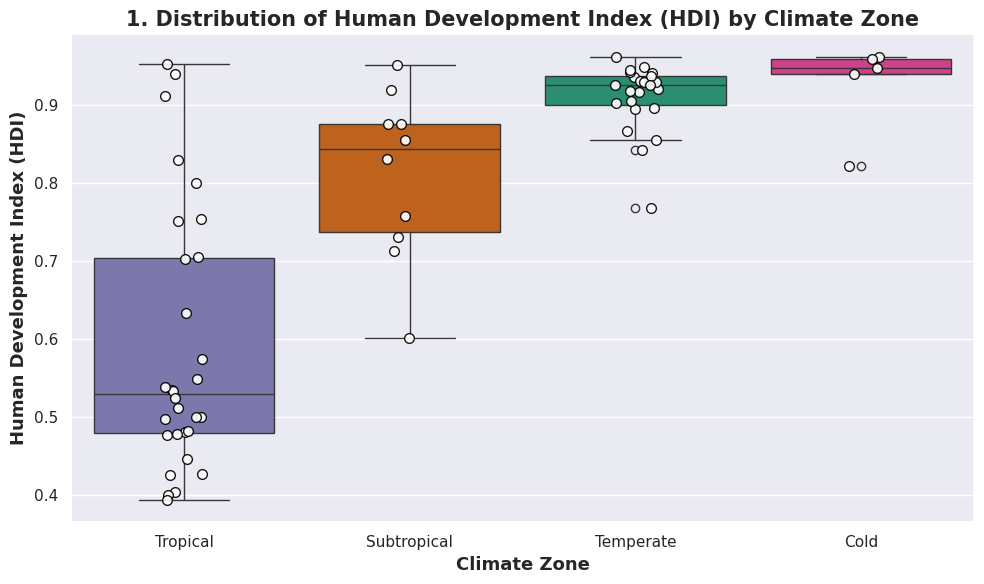

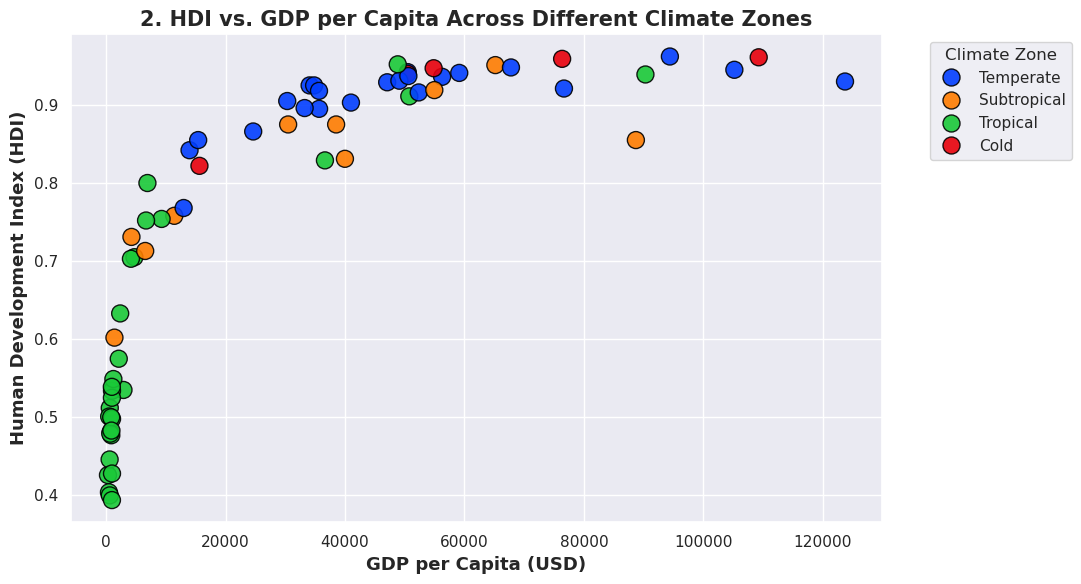

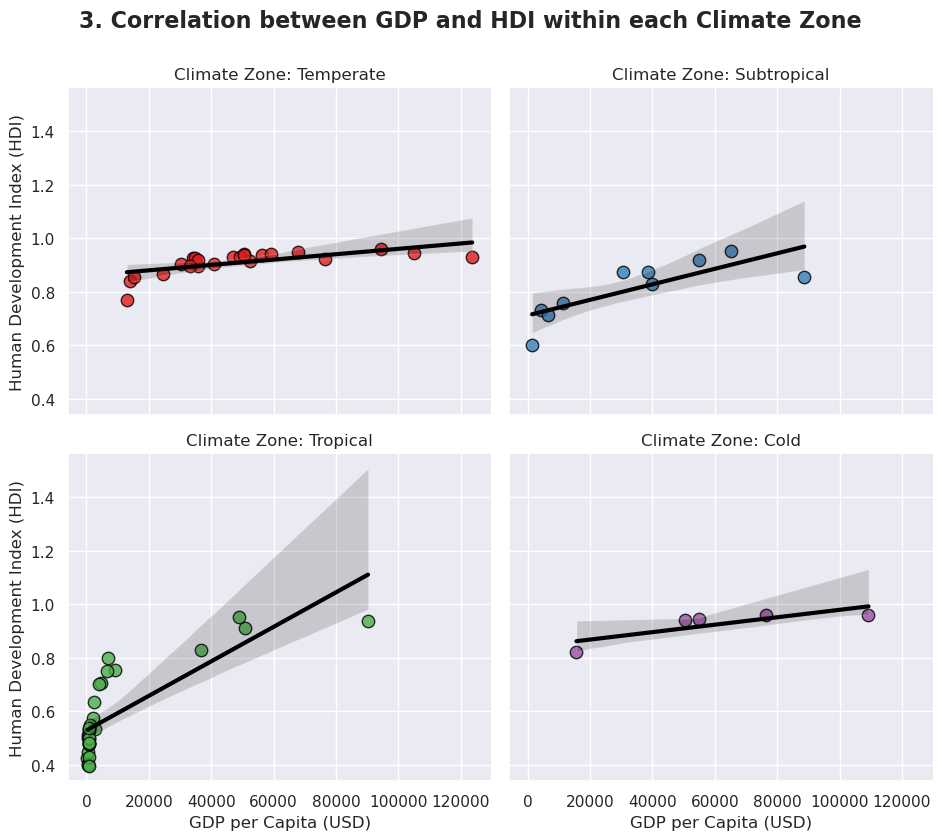

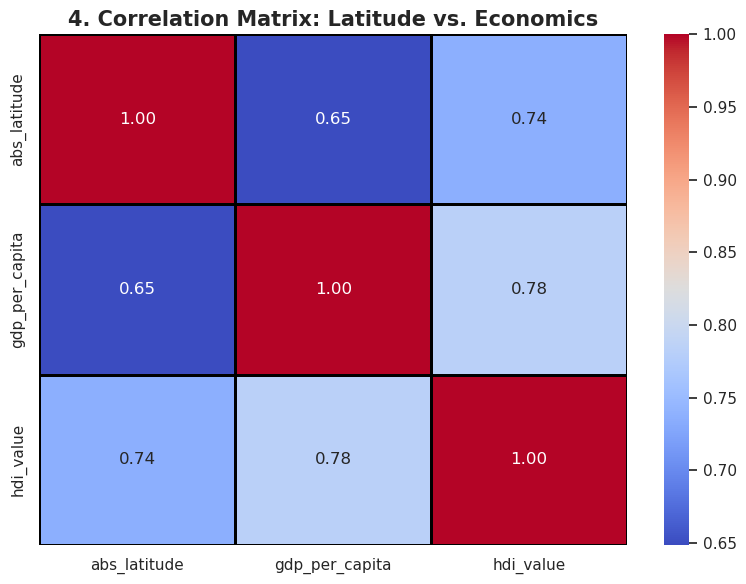

In [18]:
# Set a nice theme with a dark grid for better contrast
sns.set_theme(style="darkgrid")

# Clean data specifically for these charts
plot_df = merged_df.dropna(
    subset=['hdi_value', 'gdp_per_capita', 'climate_zone', 'abs_latitude']
).copy()

climate_order = ['Tropical', 'Subtropical', 'Temperate', 'Cold']

# Keep only climate zones that actually appear in the cleaned data
climate_order = [zone for zone in climate_order if zone in plot_df['climate_zone'].unique()]

# ==========================================
# CHART 1: Distribution of HDI by Climate Zone 
# ==========================================
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x='climate_zone',
    y='hdi_value',
    hue='climate_zone',
    palette='Dark2',
    order=climate_order,
    legend=False
)

sns.stripplot(
    data=plot_df,
    x='climate_zone',
    y='hdi_value',
    color='white',
    edgecolor='black',
    linewidth=1,
    alpha=0.9,
    size=7,
    jitter=True,
    order=climate_order
)

plt.title(
    "1. Distribution of Human Development Index (HDI) by Climate Zone",
    fontsize=15,
    fontweight='bold'
)
plt.xlabel("Climate Zone", fontsize=13, fontweight='bold')
plt.ylabel("Human Development Index (HDI)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ==========================================
# CHART 2: HDI vs. GDP per Capita 
# ==========================================
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=plot_df,
    x='gdp_per_capita',
    y='hdi_value',
    hue='climate_zone',
    palette='bright',
    s=150,
    alpha=0.9,
    edgecolor='black'
)

plt.title(
    "2. HDI vs. GDP per Capita Across Different Climate Zones",
    fontsize=15,
    fontweight='bold'
)
plt.xlabel("GDP per Capita (USD)", fontsize=13, fontweight='bold')
plt.ylabel("Human Development Index (HDI)", fontsize=13, fontweight='bold')
plt.legend(
    title='Climate Zone',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop={'size': 11}
)
plt.tight_layout()
plt.show()


# ==========================================
# CHART 3: GDP vs HDI Trendlines per Climate Zone (Faceted)
# ==========================================
g = sns.lmplot(
    data=plot_df,
    x='gdp_per_capita',
    y='hdi_value',
    hue='climate_zone',
    col='climate_zone',
    col_wrap=2,
    height=4,
    aspect=1.2,
    palette='Set1',
    scatter_kws={
        's': 80,
        'alpha': 0.8,
        'edgecolor': 'black'
    },
    line_kws={
        'linewidth': 3,
        'color': 'black'
    }
)

g.fig.suptitle(
    "3. Correlation between GDP and HDI within each Climate Zone",
    y=1.05,
    fontsize=16,
    fontweight='bold'
)

g.set_axis_labels(
    "GDP per Capita (USD)",
    "Human Development Index (HDI)"
)

g.set_titles("Climate Zone: {col_name}")

plt.show()


# ==========================================
# CHART 4: Correlation Matrix Heatmap
# ==========================================
plt.figure(figsize=(8, 6))

corr_matrix = plot_df[
    ['abs_latitude', 'gdp_per_capita', 'hdi_value']
].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=1,
    linecolor='black'
)

plt.title(
    "4. Correlation Matrix: Latitude vs. Economics",
    fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

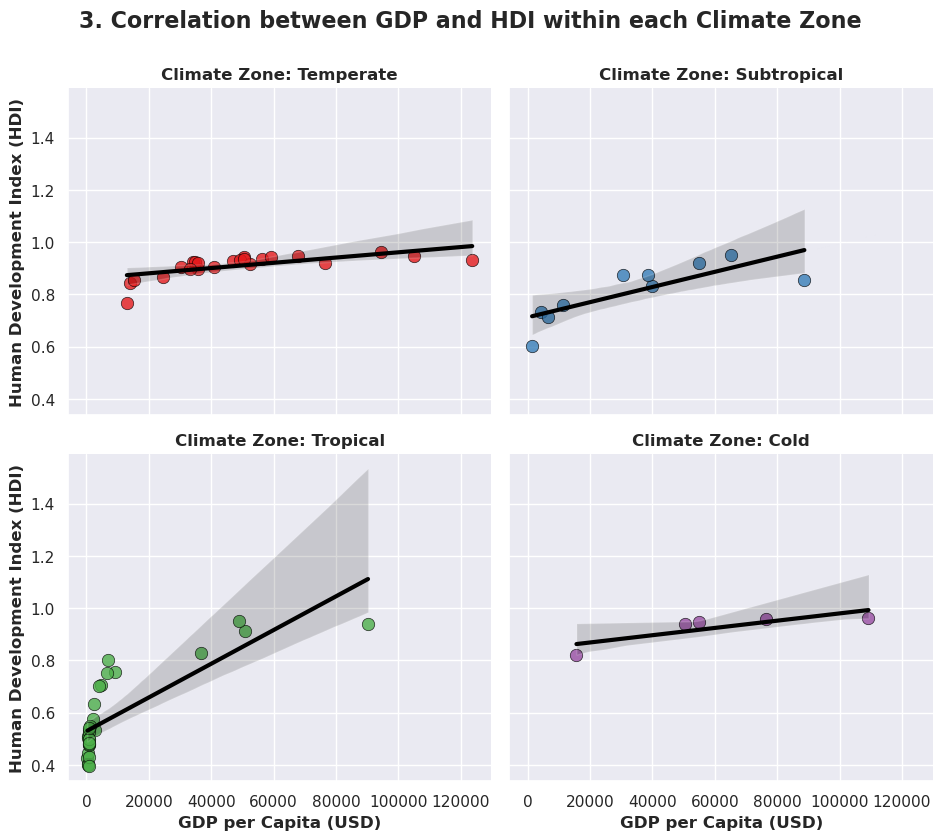

In [19]:
# ==========================================
# CHART 3: GDP vs HDI Trendlines per Climate Zone (Faceted)
# ==========================================
g = sns.lmplot(
    data=plot_df, x='gdp_per_capita', y='hdi_value', hue='climate_zone', 
    col='climate_zone', col_wrap=2, height=4, aspect=1.2, palette='Set1', 
    # FIX: Changed 'linewidth' to 'linewidths' in the line below!
    scatter_kws={'s': 80, 'alpha': 0.8, 'edgecolor': 'black', 'linewidths': 0.5},
    line_kws={'linewidth': 3, 'color': 'black'} 
)
g.fig.suptitle("3. Correlation between GDP and HDI within each Climate Zone", y=1.05, fontsize=16, fontweight='bold')
g.set_axis_labels("GDP per Capita (USD)", "Human Development Index (HDI)", fontweight='bold')
g.set_titles("Climate Zone: {col_name}", fontweight='bold')
plt.show()

## Modeling

This section builds two simple models to evaluate whether geography and development indicators help explain economic outcomes.

Model 1 uses linear regression to predict GDP per capita.

Model 2 uses logistic regression to predict whether a country is above or below the median GDP per capita in the sample.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np
import pandas as pd

# Clean modeling data
model_df = merged_df.dropna(
    subset=['gdp_per_capita', 'hdi_value', 'abs_latitude', 'region_id']
).copy()

# =========================
# MODEL 1: Linear Regression
# Predict GDP per capita
# =========================

X_linear = model_df[['hdi_value', 'abs_latitude', 'region_id']]
y_linear = model_df['gdp_per_capita']

X_train, X_test, y_train, y_test = train_test_split(
    X_linear, y_linear, test_size=0.25, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_metrics = pd.DataFrame({
    'Metric': ['R-squared', 'MAE', 'RMSE'],
    'Value': [
        r2_score(y_test, linear_predictions),
        mean_absolute_error(y_test, linear_predictions),
        np.sqrt(mean_squared_error(y_test, linear_predictions))
    ]
})

linear_metrics

,Metric,Value
0,R-squared,0.663488
1,MAE,14502.675489
2,RMSE,18350.687693


### Linear Regression Findings
The linear regression model predicts GDP per capita using HDI, absolute latitude, and region ID. The purpose is not to build a perfect model, but to test whether these features have explanatory value for economic outcomes.

In [15]:
# =========================
# MODEL 2: Logistic Regression
# Predict whether country is high income
# =========================

median_gdp = model_df['gdp_per_capita'].median()

model_df['high_income_flag'] = model_df['gdp_per_capita'].apply(
    lambda x: 1 if x >= median_gdp else 0
)

X_logistic = model_df[['hdi_value', 'abs_latitude', 'region_id']]
y_logistic = model_df['high_income_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X_logistic, y_logistic, test_size=0.25, random_state=42
)

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

logistic_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Value': [
        accuracy_score(y_test, logistic_predictions),
        precision_score(y_test, logistic_predictions),
        recall_score(y_test, logistic_predictions)
    ]
})

logistic_metrics

,Metric,Value
0,Accuracy,0.764706
1,Precision,0.714286
2,Recall,0.714286


In [16]:
confusion_matrix_df = pd.DataFrame(
    confusion_matrix(y_test, logistic_predictions),
    columns=['Predicted Low Income', 'Predicted High Income'],
    index=['Actual Low Income', 'Actual High Income']
)

confusion_matrix_df

,Predicted Low Income,Predicted High Income
Actual Low Income,8,2
Actual High Income,2,5


### Logistic Regression Findings
The logistic regression model predicts whether a country is above or below the sample median GDP per capita. This model uses the same engineered and development features, allowing us to test whether the variables help classify countries into higher- and lower-income groups.

### Conclusion

This analysis examined whether geography, specifically distance from the equator, is associated with economic development and human well-being. Using data from the World Bank, Human Development Index (HDI) datasets, and country geographic information, I combined economic, development, and geographic variables into a single dataset for analysis.

Several feature engineering techniques were applied to support the analysis, including the creation of absolute latitude, climate zone classifications, region identifiers, and a high-income indicator variable. These engineered features allowed geographic characteristics to be incorporated into both exploratory analysis and predictive modeling.

The exploratory data analysis revealed a positive relationship between GDP per capita and HDI, suggesting that countries with stronger economic performance generally experience higher levels of human development. Comparisons across climate zones and regions also demonstrated meaningful differences in average GDP and HDI values. Countries located in temperate and colder climate zones often exhibited higher average economic output and development metrics than countries located closer to the equator. However, the analysis also identified several notable exceptions, indicating that geography alone cannot fully explain differences in prosperity across countries.

The SQL analysis reinforced these findings by comparing countries across regions and climate zones, identifying countries that performed above their regional averages, and highlighting patterns in economic development that were not immediately visible through descriptive statistics alone. The combination of SQL and Python provided multiple perspectives on the same research question and helped validate key findings throughout the project.

The linear regression and logistic regression models further demonstrated that geographic and development-related variables contain predictive information regarding economic outcomes. While the models were not designed to maximize predictive accuracy, they provided additional evidence that variables such as HDI, latitude, and climate classifications are associated with GDP per capita and broader measures of development.

There are several limitations to this analysis. The sample contains a limited number of countries and uses latitude as a simplified proxy for climate and geography. Many factors that influence economic development were not included, such as education levels, institutional quality, trade openness, infrastructure, political stability, internet penetration, population dynamics, and natural resource endowments. As a result, the findings should be interpreted as evidence of association rather than causation.

If additional time and data were available, future research would expand the country sample and incorporate additional development indicators such as internet usage rates, education attainment, population size, governance metrics, trade activity, and urbanization rates. It would also be interesting to include the prevalence of malaria, considering the original Tropical Underdevelopment theory cited vulnerability to diseases such as malaria as one of the core reasons for this phenomenon. Including these variables would provide a more comprehensive understanding of the factors that contribute to economic prosperity and human development around the world.

Overall, the results suggest that geography may influence economic outcomes, but it is only one component of a much larger system of economic, social, and institutional factors that shape long-term development.